# Image Script: Cleartext Traffic Settings

This script produces Figure 2 (Section 5.2)

In [ ]:
import pymongo

import pandas as pd

client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["webview"]
manifest_info_collection = db["manifest_info"]
network_info_collection = db["network_info"]

def print_latex_macro(name: str, value: str):
    print(f"\\newcommand{{\\{name}}}{{{value}}}")

In [2]:
pipeline = [
    {
        "$lookup": {
            "from": "network_info",
            "localField": "package_name",
            "foreignField": "package_name",
            "as": "network_info"
        }
    },
    {
        "$lookup": {
            "from": "app_info",
            "localField": "package_name",
            "foreignField": "package_name",
            "as": "app_info_collection"
        }
    },
    {
        "$project": {
            "package_name": 1,
            "target_sdk": 1,
            "category": { "$arrayElemAt": [ "$app_info_collection.genre", 0 ] },
            "installs": { "$arrayElemAt": [ "$app_info_collection.min_installs", 0 ] },
            "released": { "$arrayElemAt": [ "$app_info_collection.released", 0 ] },
            "disallowed_domains": { "$first": "$network_info.disallowed_domains" },
            "allowed_domains": { "$first": "$network_info.allowed_domains" }
        }
    }
]

results = list(manifest_info_collection.aggregate(pipeline, allowDiskUse=True))

final_result = []
for doc in results:
    res = {}
    target_sdk = doc.get("target_sdk", -1)
    res["target_sdk"] = target_sdk
    res["category"] = doc.get("category", "Unknown")
    res["package_name"] = doc.get("package_name", None)
    res["installs"] = doc.get("installs", 0)
    res["released"] = doc.get("released", None)
    disallowed = list(doc.get("disallowed_domains", []))
    allowed = list(doc.get("allowed_domains", []))
    
    n = None
    
    if "*" in allowed and len(disallowed) == 0:
        n = "ALL_ALLOWED"
    elif "*" in allowed and "*" in disallowed:
        n = "CONFLICTING"
    elif "*" in allowed and len(disallowed) > 0:
        n = "DENY_LIST"
    elif "*" in disallowed and len(allowed) > 0:
        n = "ALLOW_LIST"
    elif "*" in disallowed and len(allowed) == 0:
        n = "ALL_DISALLOWED"
    elif len(allowed) == 0 and len(disallowed) == 0:
        n = "UNKNOWN"
    else:
        n = "CUSTOM"
    res["allowed"] = n
    final_result.append(res)

In [3]:
df = pd.DataFrame(final_result)
df['status_label'] = df['allowed'].map({
    "ALL_ALLOWED": "All Allowed",
    "ALL_DISALLOWED": "All Disallowed",
    "DENY_LIST": "Denylist",
    "ALLOW_LIST": "Allowlist",
    "CUSTOM": "Default",
    "UNKNOWN": "Unknown",
    "CONFLICTING": "Default"
})

palette = {
    "All Disallowed":  "#1b7837",
    "Allowlist":    "#a6d96a",

    "All Allowed": "#b2182b",
    "Denylist":      "#ef8a62",
    "Other":        "#737373",
    "Default": "#abcdef",
}

hue_order = ["All Allowed", "Denylist", "Unknown", "Other", "Allowlist", "All Disallowed"]

def human_format(num):
    if num == 0:
        return "0"
    if num < 1000:
        return str(num)
    elif num < 1_000_000:
        # if it ends with .0, remove it
        formatted = f"{num/1000:.1f}K"
        if formatted.endswith('.0K'):
            return formatted.replace('.0K', 'K')
        return formatted
    else:
        return f"{num/1_000_000:.1f}M"

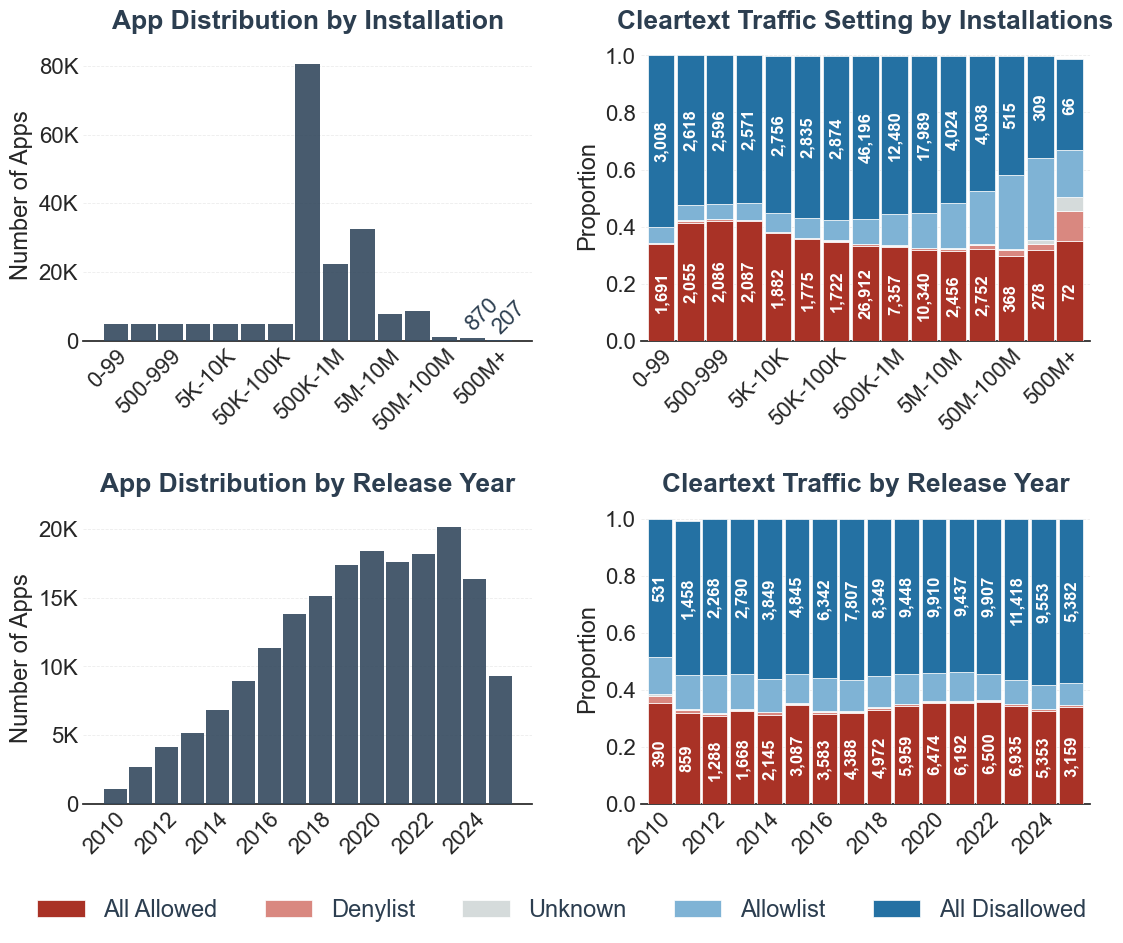

In [4]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# --- 1. Aesthetic Configuration ---
palette = {
    'All Allowed': '#A93226',    
    'Denylist': '#D98880',       
    'Unknown': '#D5DBDB',          
    'Allowlist': '#7FB3D5',      
    'All Disallowed': '#2471A3',
    "Default": "#abcdef",
}
hue_order = ['All Allowed', 'Denylist', 'Unknown', 'Allowlist', 'All Disallowed']

plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['pdf.fonttype'] = 42  # <--- ADD THIS to fix the Type 3 error
plt.rcParams['ps.fonttype'] = 42   # <--- ADD THIS to fix the Type 3 error
plt.rcParams['text.color'] = '#2c3e50'
plt.rcParams['axes.labelsize'] = 16  # X and Y axis titles
plt.rcParams['xtick.labelsize'] = 16   # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 16   # Y-axis tick labels
BAR_COLOR = "#34495e"

# Create a 2x2 grid - Increased figsize slightly for labels
fig, axes = plt.subplots(2, 2, figsize=(11, 9.5), constrained_layout=True)

fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.15, hspace=0.08, wspace=0.08)

human_formatter = FuncFormatter(lambda x, pos: human_format(x))

# --- DATA PREPARATION ---
# (Assumes your data preparation logic is already executed)# --- DATA PREPARATION ---

# (Logic remains identical to your provided snippet)
new_df = df.copy()

bins = [0, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000, 10000000, 50000000, 100000000, 500000000, float('inf')]
new_labels = ['0-99', '100-499', '500-999', '1K-5K', '5K-10K', '10K-50K', '50K-100K', '100K-500K', '500K-1M', '1M-5M', '5M-10M', '10M-50M', '50M-100M', '100M-500M', '500M+']
new_df['install_bucket'] = pd.cut(new_df['installs'], bins=bins, labels=new_labels, right=False, include_lowest=True)
count_table_inst = new_df['install_bucket'].value_counts().sort_index()

current_df = df.copy()
current_df["released_year"] = pd.to_datetime(current_df["released"], errors='coerce').dt.year
current_df = current_df[current_df["released_year"].notnull() & (current_df["released_year"] != 0)]
current_df["released_year"] = current_df["released_year"].astype(int)
count_table_year = current_df['released_year'].value_counts().sort_index()

# --- 2. ROW 1: INSTALLATION ANALYSIS ---

# [0, 0] App Distribution (Installs)
bars1 = axes[0, 0].bar(count_table_inst.index, count_table_inst.values, color=BAR_COLOR, alpha=0.9, zorder=3, width=0.9)
axes[0, 0].set_title('App Distribution by Installation', fontsize=19, pad=15, weight='bold')
#axes[0, 0].bar_label(bars1, labels=[human_format(x) for x in count_table_inst.values], padding=2, fontsize=16)
labels1 = axes[0, 0].bar_label(
    bars1, 
    labels=[human_format(x) if x < 1000 else "" for x in count_table_inst.values], 
    padding=2, 
    fontsize=16, 
    rotation=45,
)

for label in labels1:
    label.set_rotation(45)
    label.set_horizontalalignment('center')
    label.set_verticalalignment('bottom')
    x, y = label.get_position()
    # Subtracting a small value from x moves it slightly to the left to center it better
    label.set_position((x + 7, y))


axes[0, 0].set_ylabel('Number of Apps', fontsize=17)
#axes[0, 0].set_xlabel('Installations', fontsize=14, labelpad=10)

# [0, 1] Cleartext Traffic (Installs)
ct_inst = pd.crosstab(new_df['install_bucket'], new_df['status_label'], normalize='index')[hue_order]
ct_inst_counts = pd.crosstab(new_df['install_bucket'], new_df['status_label'])[hue_order]
ct_inst.plot(kind='bar', stacked=True, ax=axes[0, 1], color=[palette[col] for col in hue_order], 
             width=0.9, edgecolor='white', linewidth=0.5, legend=False, zorder=3)
axes[0, 1].set_title('Cleartext Traffic Setting by Installations', fontsize=19, pad=15, weight='bold')
axes[0, 1].set_ylabel('Proportion', fontsize=17)
for bar, count in zip(axes[0, 1].containers[0], ct_inst_counts['All Allowed']):
    if bar.get_height() <= 0:
        continue
    y = bar.get_y() + bar.get_height() / 2
    va = 'center'
    if bar.get_height() < 0.06:
        y = bar.get_y() + bar.get_height() + 0.01
        va = 'bottom'
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, y, f"{int(count):,}",
                    ha='center', va=va, color='white', fontsize=12, fontweight='bold', rotation=90, rotation_mode='anchor')
for bar, count in zip(axes[0, 1].containers[-1], ct_inst_counts['All Disallowed']):
    if bar.get_height() <= 0:
        continue
    y = bar.get_y() + bar.get_height() / 2
    va = 'center'
    if bar.get_height() < 0.06:
        y = bar.get_y() + bar.get_height() + 0.01
        va = 'bottom'
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, y, f"{int(count):,}",
                    ha='center', va=va, color='white', fontsize=12, fontweight='bold', rotation=90, rotation_mode='anchor')

# --- 3. ROW 2: RELEASE DATE ANALYSIS ---

# [1, 0] Distribution
bars2 = axes[1, 0].bar(count_table_year.index.astype(str), count_table_year.values, color=BAR_COLOR, alpha=0.9, zorder=3, width=0.9,)
axes[1, 0].set_title('App Distribution by Release Year', fontsize=19, pad=15, weight='bold')
#axes[1, 0].bar_label(bars2, labels=[human_format(x) for x in count_table_year.values], padding=2, fontsize=8)
axes[1, 0].set_ylabel('Number of Apps', fontsize=17)

# [1, 1] Cleartext
ct_year = pd.crosstab(current_df['released_year'], current_df['status_label'], normalize='index')[hue_order]
ct_year_counts = pd.crosstab(current_df['released_year'], current_df['status_label'])[hue_order]
ct_year.plot(kind='bar', stacked=True, ax=axes[1, 1], color=[palette[col] for col in hue_order], 
             width=0.9, edgecolor='white', linewidth=0.5, legend=False, zorder=3)
axes[1, 1].set_title('Cleartext Traffic by Release Year', fontsize=19, pad=15, weight='bold')
axes[1, 1].set_ylabel('Proportion', fontsize=17)
for bar, count in zip(axes[1, 1].containers[0], ct_year_counts['All Allowed']):
    if bar.get_height() <= 0:
        continue
    y = bar.get_y() + bar.get_height() / 2
    va = 'center'
    if bar.get_height() < 0.06:
        y = bar.get_y() + bar.get_height() + 0.01
        va = 'bottom'
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, y, f"{int(count):,}",
                    ha='center', va=va, color='white', fontsize=12, fontweight='bold', rotation=90, rotation_mode='anchor')
for bar, count in zip(axes[1, 1].containers[-1], ct_year_counts['All Disallowed']):
    if bar.get_height() <= 0:
        continue
    y = bar.get_y() + bar.get_height() / 2
    va = 'center'
    if bar.get_height() < 0.06:
        y = bar.get_y() + bar.get_height() + 0.01
        va = 'bottom'
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, y, f"{int(count):,}",
                    ha='center', va=va, color='white', fontsize=12, fontweight='bold', rotation=90, rotation_mode='anchor')


# --- 4. GLOBAL REFINEMENTS ---
for ax in axes.flat:
    sns.despine(ax=ax, left=True)
    ax.grid(axis='y', linestyle='--', linewidth=0.6, color='#e0e0e0', alpha=0.6, zorder=0)
    ax.tick_params(axis='both', labelsize=16)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=16)
    # only show every other x-tick label if there are too many
    if len(ax.get_xticklabels()) > 10:
        for i, label in enumerate(ax.get_xticklabels()):
            if i % 2 != 0:
                label.set_visible(False)
    #ax.set_title("") # Remove individual titles
    
axes[0, 0].set_xlabel('')
axes[0, 1].set_xlabel('')
axes[1, 0].set_xlabel('')
axes[1, 1].set_xlabel('')

for i in [0, 1]:
    axes[i, 0].yaxis.set_major_formatter(human_formatter)
    axes[i, 1].set_ylim(0, 1.02) # Tighter Y-limit


handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=5, 
           frameon=False, fontsize=17)

plt.show()
#fig.savefig(os.path.join(".", "figures-out", "cleartext_traffic_overview.pdf"), bbox_inches='tight')